In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import pickle
import mygene
from pathlib import Path
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Inital setting for plot size
from matplotlib import rcParams
FIGSIZE = (4, 4)
rcParams["figure.figsize"] = FIGSIZE

from icepop.data import HomologyData
from icepop.convert_score import CrossSpeciesScoreConverter

In [2]:
adata = sc.read('../data/mouse_colon/mouse_colon_normed.h5ad')
adata.obs['metacell'] = pd.read_csv('../results/mouse_colon_mc/mc_assign.csv', header=None, index_col=None)[0].values

In [3]:
# convert mouse to human genes
ortho_map = HomologyData(sp='mmusculus').load()
m2h = {}
for h, m in ortho_map.items():
    for i in m:
        m2h[i] = h
m2h['116903'] = '797'

adata.var['hentrez'] = [m2h[i] if i in m2h else None for i in adata.var_names]
entrezid = adata.var['hentrez'][~pd.isna(adata.var['hentrez'])].values

mg = mygene.MyGeneInfo()
res = mg.querymany(
    entrezid,
    scopes="entrezgene",
    fields="symbol",
    species="human"
)

entrez_to_symbol = {
    r["query"]: r.get("symbol", None)
    for r in res
}
adata.var['hsymbol'] = [entrez_to_symbol[i] if i in entrez_to_symbol else None for i in adata.var['hentrez']]

adata = adata[:, ~pd.isna(adata.var['hsymbol'])].copy()
adata.var_names = adata.var['hsymbol']

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [4]:
indir = '../results/mouse_colon_icepop'

trait = 'asd'
mc_asso = f'{indir}/metacell__trait-{trait}.csv'
ct_asso = f'{indir}/celltype__trait-{trait}.csv'

mc_df = pd.read_csv(mc_asso, header=0, index_col=None)
ct_df = pd.read_csv(ct_asso, header=0, index_col=None)
ct_df.to_csv('../paper/suppdata/ASD_colon_icepop.tsv', header=True, index=False, sep='\t')

mc_df = mc_df.set_index('metacell')
ct_df = ct_df.set_index('cell_type')

# add mc count in each ct
min_purity = 0.2
freq_df = pd.crosstab(adata.obs['cell_type'], adata.obs['metacell'])
freq_df = freq_df.div(freq_df.sum(0))
ct2meta = {ct: np.asarray(row[row >= min_purity].index) for ct, row in freq_df.iterrows()}
ct_df['n_mc'] = [len(ct2meta[ct]) for ct in ct_df.index]

In [5]:
def capitalize_first_if_not_all_caps(s):
    if s.isupper():
        return s
    return s[0].upper() + s[1:]

def plot_tsne(
    adata, col,
    cmap='Reds', palette=None,
    alpha=0.6, vmin=None, vmax=None,
    title=None, size=20, outfile=None, cbar=None,
    fontsize=14, rasterize=False
):
    # Determine if we use custom scaling
    use_limits = isinstance(vmin, (float, int)) and isinstance(vmax, (float, int))
    
    # Generate the plot
    if palette is None:
        ax = sc.pl.tsne(
            adata,
            color=col,
            show=False,
            size=size,
            cmap=cmap,
            alpha=alpha,
            vmin=vmin if use_limits else None,
            vmax=vmax if use_limits else None,
        ) 
    else:
        adata.obs[col] = adata.obs[col].astype("category")
        ax = sc.pl.tsne(
            adata,
            color=col,
            show=False,
            size=size,
            palette=palette,
            alpha=alpha,
            vmin=vmin if use_limits else None,
            vmax=vmax if use_limits else None,
        )

    ax.set_xlabel('tSNE1', fontsize=fontsize)
    ax.set_ylabel('tSNE2', fontsize=fontsize)

    if rasterize:
        # --- RASTERIZE POINTS ---
        for coll in ax.collections:
            coll.set_rasterized(True)

    # 1. Remove the top and right "border" (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 2. Ensure bottom and left spines are visible
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

    # 3. Add ticks and labels back
    ax.set_xticks([]) # Or use ax.xaxis.set_visible(True) for default behavior
    ax.set_yticks([])
    
    # If you want numeric tick labels, use these instead:
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

    if cbar:
        # get current figure
        fig = plt.gcf()
        
        # find colorbar and set label
        acbar = fig.axes[-1]   # colorbar is usually the last axis
        acbar.set_ylabel(cbar, rotation=270, labelpad=15, fontsize=14)

    # 4. Remove title
    if not title:
        ax.set_title("")
    else:
        ax.set_title(title)

    if outfile:
        plt.savefig(outfile, bbox_inches='tight')
    else:
        plt.show()

def plot_opa_tsne(
    adata, col,
    palette=None,
    alpha=0.6,
    alpha_bg=0.1,  # opacity for "Not associated"
    vmin=None, vmax=None,
    title=None, size=None, outfile=None, cbar=None,
    fontsize=14, rasterize=False,
    bg_label="Not associated",
    figsize=(5, 5)
):

    use_limits = isinstance(vmin, (float, int)) and isinstance(vmax, (float, int))
    coords = adata.obsm["tsne"]

    # Auto size like scanpy default
    if size is None:
        size = 120000 / adata.n_obs

    fig, ax = plt.subplots(figsize=figsize)

    # ----------------------------
    # CASE 1: CATEGORICAL
    # ----------------------------
    if pd.api.types.is_categorical_dtype(adata.obs[col]):

        categories = adata.obs[col].cat.categories

        if palette is None:
            palette = sc.pl.palettes.default_20[:len(categories)]

        for cat, color in zip(categories, palette):
            mask = adata.obs[col] == cat
            this_alpha = alpha_bg if cat == bg_label else alpha

            sc = ax.scatter(
                coords[mask, 0],
                coords[mask, 1],
                c=color,
                s=size,
                alpha=this_alpha,
                label=cat,
                rasterized=rasterize
            )

        # Legend on right
        ax.legend(
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            markerscale=4
        )

    # ----------------------------
    # Styling
    # ----------------------------
    ax.set_xlabel('tSNE1', fontsize=fontsize)
    ax.set_ylabel('tSNE2', fontsize=fontsize)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

    if title:
        ax.set_title(title)

    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, bbox_inches='tight')
    else:
        plt.show()


def tsne_filter(
    adata,
    top=100.0, bottom=100.0,
    left=100.0, right=100.0
):
    X = adata.obsm["tsne"]
    x, y = X[:, 0], X[:, 1]
    
    mask = (
        (x > np.percentile(x, 100 - left)) &
        (x < np.percentile(x, right)) &
        (y > np.percentile(y, 100 - bottom)) &
        (y < np.percentile(y, top))
    )
    n_remove = adata.shape[0] - mask.sum()
    print(f'{n_remove} cell removed')
    print("%.2f%% cells left" % (mask.sum() / adata.shape[0] * 100))
    return adata[mask, :].copy()

/mnt/ufs18/rs-032/FishEvoDevoGeno/Hao/icepop_analysis/.venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


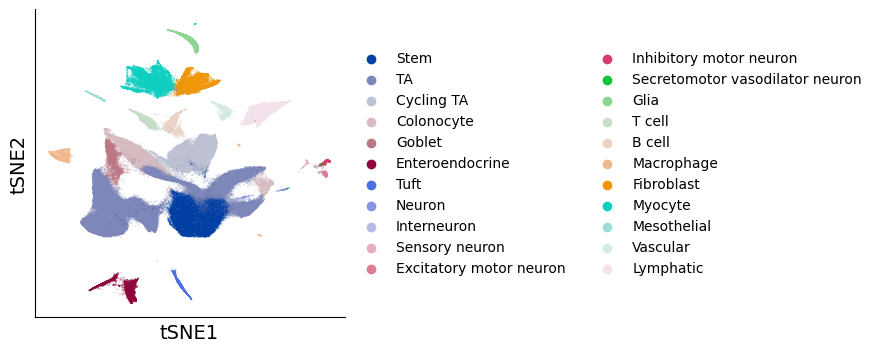

In [6]:
adata.obs['cell_type_rename'] = [capitalize_first_if_not_all_caps(i.replace('_', ' ')) for i in adata.obs['cell_type']]
adata.obs["cell_type_rename"] = adata.obs["cell_type_rename"].astype('category')

new_order = [
    # Stem / progenitors
    "Stem", "TA", "Cycling TA",
    # Epithelial lineages
    "Colonocyte", "Goblet", "Enteroendocrine", "Tuft",
    # Neuronal lineages
    "Neuron", "Interneuron", "Sensory neuron", "Excitatory motor neuron", "Inhibitory motor neuron", "Secretomotor vasodilator neuron",
    # Glia
    "Glia",
    # Immune cells
    "T cell", "B cell", "Macrophage",
    # Mesenchymal / stromal
    "Fibroblast", "Myocyte", "Mesothelial",
    # Vascular / lymphatic
    "Vascular", "Lymphatic",
]
adata.obs["cell_type_rename"] = adata.obs["cell_type_rename"].cat.reorder_categories(new_order)

plot_tsne(adata, 'cell_type_rename', size=3, alpha=0.3, rasterize=True, outfile='../paper/supp/colon_celltypes.pdf')

In [7]:
ct_df['discovery'] = ct_df['q'] <= 0.1
associated_cts = ct_df[ct_df['discovery']].index.values
ct_df[ct_df['discovery']]

,beta,se,z,p,q,sig_pct,n_mc,discovery
cell_type,,,,,,,,
Sensory_neuron,3.716570,1.579601,2.352854,0.010115,0.076789,0.800000,8,True
Secretomotor_vasodilator_neuron,5.292866,2.221222,2.382862,0.010471,0.076789,0.552448,3,True
Inhibitory_motor_neuron,6.360080,2.524125,2.519717,0.005310,0.076789,0.637615,10,True


In [8]:
# seismic
seismic_df = pd.read_csv('../results/mouse_colon_seismic/asd.tsv', header=0, index_col=None, sep='\t')
seismic_df.to_csv('../paper/suppdata/ASD_colon_seismic.tsv', header=True, index=False, sep='\t')
seismic_df[seismic_df['FDR'] <= 0.1]

,cell_type,pvalue,FDR
0,Secretomotor_vasodilator_neuron,0.001598,0.035147


In [9]:
# scdrs
scdrs_df = pd.read_csv('../results/mouse_colon_scDRS_downstream/asd.genes.scdrs_group.cell_type', header=0, index_col=None, sep='\t')
scdrs_df['q'] = multipletests(scdrs_df['assoc_mcp'], method='fdr_bh')[1]
scdrs_df.to_csv('../paper/suppdata/ASD_colon_scdrs.tsv', header=True, index=False, sep='\t')
scdrs_df[scdrs_df['q'] <= 0.1]

,group,n_cell,n_ctrl,assoc_mcp,assoc_mcz,hetero_mcp,hetero_mcz,n_fdr_0.05,n_fdr_0.1,n_fdr_0.2,q


## check overall disease associated cell types

/mnt/ufs18/rs-032/FishEvoDevoGeno/Hao/icepop_analysis/.venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


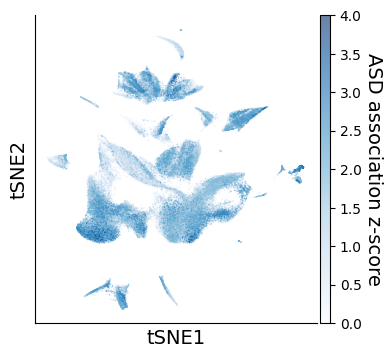

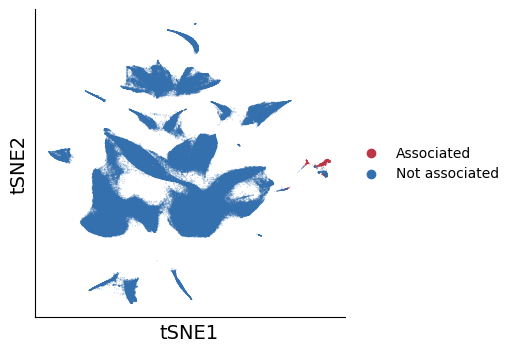

In [10]:
adata.obs['ct_discovery'] = list(ct_df.loc[adata.obs['cell_type'], 'discovery'])
adata.obs['mc_t'] = [mc_df.loc[mc, 'z'] if mc in mc_df.index else 0.0 for mc in adata.obs['metacell']]
plot_tsne(adata, 'mc_t', cmap='Blues', vmin=0.0, vmax=4.0, size=3, cbar='ASD association z-score', rasterize=True, outfile='../paper/supp/colon_zscore.pdf')

adata.obs['ct_discovery'] = np.where(adata.obs['ct_discovery'], 'Associated', 'Not associated')
plot_tsne(adata, 'ct_discovery', size=3, alpha=0.3, cmap=None, palette=['#bc3646', '#3570ae'], rasterize=True, outfile='../paper/supp/colon_bin.pdf')

/mnt/ufs18/rs-032/FishEvoDevoGeno/Hao/icepop_analysis/.venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


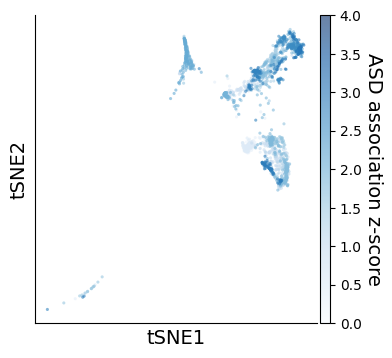

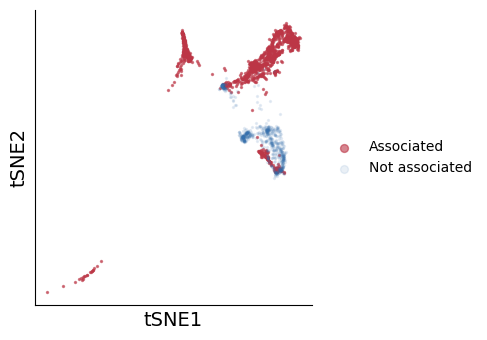

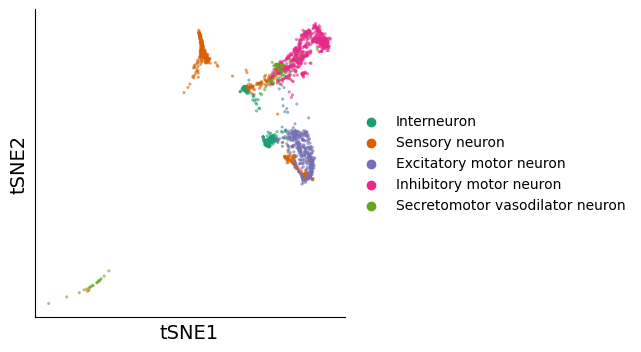

In [11]:
neuron_adata = adata[adata.obs['cell_type'].str.contains('neuron')].copy()
plot_tsne(neuron_adata, 'mc_t', cmap='Blues', vmin=0.0, vmax=4.0, alpha=0.6, cbar='ASD association z-score', outfile='../paper/main/neuron_tval.pdf')
plot_opa_tsne(neuron_adata, 'ct_discovery', size=2, alpha=0.6, figsize=(5, 3.5), palette=['#bc3646', '#3570ae'], outfile='../paper/main/neuron_bin.pdf')
palette = [
    "#1B9E77",  # teal
    "#D95F02",  # orange
    "#7570B3",  # purple
    "#E7298A",  # magenta
    "#66A61E"   # olive green
]
plot_tsne(neuron_adata, 'cell_type_rename', alpha=0.6, cmap=None, palette=palette, outfile='../paper/main/neuron_ct.pdf')

## Sensory neuron

In [12]:
ct = 'Sensory_neuron'
freq_df = pd.crosstab(adata.obs['cell_type'], adata.obs['metacell'])
freq_df = freq_df.div(freq_df.sum(0))
ct_freq_df = freq_df.loc[ct, :][freq_df.loc[ct, :] > 0].sort_values()
high_pur_metacells = ct_freq_df[ct_freq_df >= 0.3].index.values

4 cell removed
98.95% cells left


/mnt/ufs18/rs-032/FishEvoDevoGeno/Hao/icepop_analysis/.venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


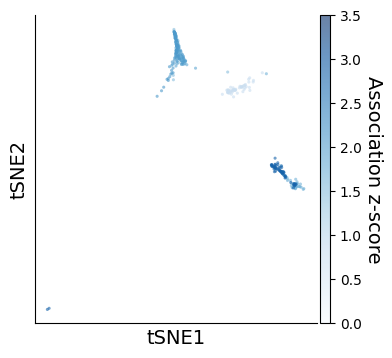

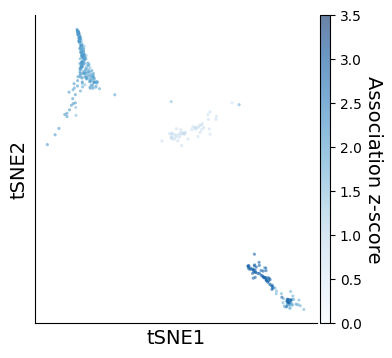

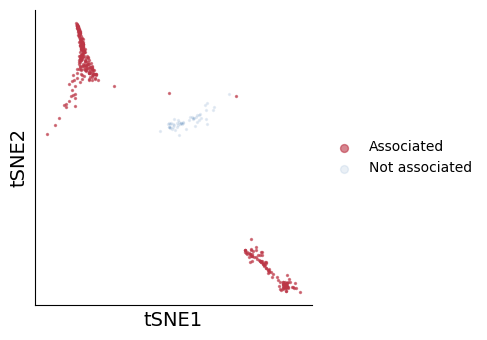

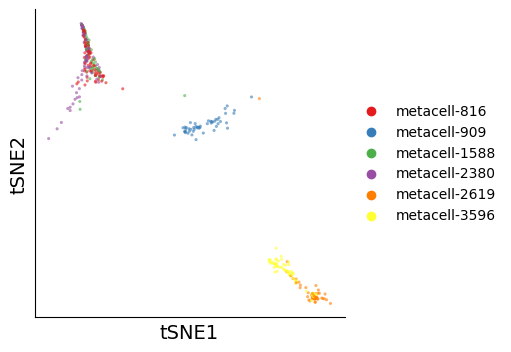

In [13]:
sub_adata = adata[(adata.obs['cell_type'] == ct)].copy()

metacells = mc_df.index.values
purity = freq_df.loc[ct, metacells].values
mc_p = mc_df['p'].values
p = mc_p[purity > 0]
pos_mcs = metacells[np.argwhere(purity > 0).ravel()]
w = purity[purity > 0]
w = w / w.sum() * w.size
q = multipletests(p / w, method='fdr_bh')[1]
mc2q = dict(zip(pos_mcs, q))

sub_adata.obs['mc_z'] = list(mc_df.loc[sub_adata.obs['metacell'], 'z'])
c_q = np.asarray([
    mc2q[mc] if mc in mc2q else 1.0
    for mc in sub_adata.obs['metacell']
])
sub_adata.obs['mc_discovery'] = np.where(c_q <= 0.1, 'Associated', 'Not associated')

sub_adata = sub_adata[(sub_adata.obs['metacell'].isin(high_pur_metacells))].copy()

plot_tsne(sub_adata, 'mc_z', cmap='Blues', vmin=0.0, vmax=3.5, outfile='../paper/supp/SN_tval_full.pdf', cbar='Association z-score')
sub_adata = tsne_filter(sub_adata, left=99.5)
plot_tsne(sub_adata, 'mc_z', cmap='Blues', vmin=0.0, vmax=3.5, outfile='../paper/main/SN_tval.pdf', cbar='Association z-score')
plot_opa_tsne(sub_adata, 'mc_discovery', alpha=0.6, size=2, figsize=(5, 3.5), palette=['#bc3646', '#3570ae'], outfile='../paper/main/SN_bin.pdf')
plot_tsne(sub_adata, 'metacell', palette=sns.color_palette("Set1", n_colors=6), outfile='../paper/supp/SN_mc.pdf')

/mnt/ufs18/rs-032/FishEvoDevoGeno/Hao/icepop_analysis/.venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


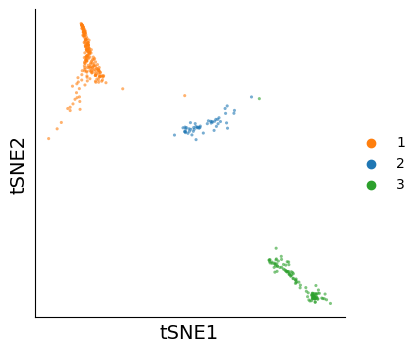

In [14]:
group_idx = []
for mc in sub_adata.obs['metacell']:
    if mc in ['metacell-816', 'metacell-2380', 'metacell-1588']:
        group_idx.append('1')
    elif mc in ['metacell-909']:
        group_idx.append('2')
    elif mc in ['metacell-2619', 'metacell-3596']:
        group_idx.append('3')
sub_adata.obs['cell_group'] = group_idx
palette = {
    "1": "#ff7f0e",
    "2": "#1f77b4",
    "3": "#2ca02c",
}
plot_tsne(sub_adata, 'cell_group', palette=palette)

In [15]:
sc.tl.rank_genes_groups(
    sub_adata,
    groupby="cell_group",   # column in adata.obs
)
c1_df = sc.get.rank_genes_groups_df(sub_adata, group='1')
c2_df = sc.get.rank_genes_groups_df(sub_adata, group='2')
c3_df = sc.get.rank_genes_groups_df(sub_adata, group='3')

In [16]:
c1_df.head(20)['names'].values

array(['DGKG', 'ZNF804A', 'NMU', 'EFR3A', 'MGAT4C', 'VGLL3', 'NGFR',
       'ANO2', 'CNTN5', 'CNTNAP2', 'CBLN2', 'CDH8', 'CDH6', 'SLC35D3',
       'PCDH9', 'SPOCK3', 'HTR3B', 'HTR3A', 'TBX2', 'KCNT2'], dtype=object)

In [17]:
c2_df.head(20)['names'].values

array(['NTNG1', 'NALF1', 'SLC44A5', 'FRMPD4', 'GNG2', 'RARB', 'GRID1',
       'PITPNC1', 'ETV1', 'KCND2', 'CD24', 'AUTS2', 'KCNC2', 'PDE4B',
       'NSG1', 'NAV3', 'GPC6', 'NEFL', 'MEIS1', 'ARHGAP28'], dtype=object)

In [18]:
c3_df.head(20)['names'].values

array(['PCDH15', 'LRP1B', 'NRG3', 'TAFA2', 'GRIA2', 'EML6', 'DLGAP2',
       'GRIP1', 'GFRA2', 'KCNMA1', 'GALNTL6', 'NLGN1', 'MDGA2', 'BNC2',
       'SLIT3', 'PLCXD3', 'LRRTM4', 'SEMA6D', 'RYR2', 'PDE4B'],
      dtype=object)

/mnt/ufs18/rs-032/FishEvoDevoGeno/Hao/icepop_analysis/.venv/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


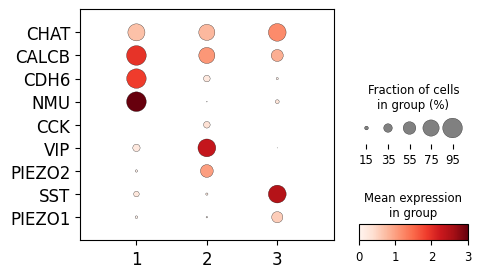

In [19]:
genes = [
   "CHAT", "CALCB", "CDH6", "NMU", "CCK", "VIP", "PIEZO2", "SST", "PIEZO1"
]
dp = sc.pl.dotplot(
    sub_adata,
    var_names=genes,
    groupby="cell_group",
    figsize=(5, 3),   # width, height in inches
    dot_min=0.05,
    dot_max=0.95,
    swap_axes=True,
    show=False,
    vmin=0,
    vmax=3,
    return_fig=True
)
ax = dp.get_axes()["mainplot_ax"]
ax.tick_params(axis="x", labelrotation=0, labelsize=12)
ax.tick_params(axis="y", labelsize=12)
dp.fig.savefig("../paper/main/SN_marker.pdf", bbox_inches="tight")

## ASD genes that have direct effect on sensory neuron
### Disruption of sensory processing in sensory neuron
### Cntnap2
- 10.1101/2023.04.17.537221
    - ASD-related synaptic cell-adhesion molecule important for sensory processing.
- 10.1016/j.biopsych.2023.03.014 (but described in Cortical Excitatory Neuron)
    - CNTNAP2 encodes CASPR2, a single-pass transmembrane protein that belongs to the neurexin family of cell adhesion molecules. These proteins have a variety of functions in developing neurons, including connecting presynaptic and postsynaptic neurons, and mediating signaling across the synapse.
    - Live imaging of excitatory neuronal growth showed that loss of CNTNAP2 reduced neurite branching and overall neuronal complexity.
### Disruption of neuronal progenitor migration lead to reduced sensory neuron population
### Cdh8, Cdh2
- 10.1038/s41467-025-57342-3
### Disruption in serotonin receptor in sensory neuron
### Htr3a
- 10.1007/s10048-009-0171-7

## Comparison strategies
- We expect high risk ASD genes are more enriched in sensory neuron specific genes than IFN

Synaptic "Wiring" Errors: Many ASD-linked genes (like NLGN3, SHANK3, and CNTNAP2) encode proteins that act as the "glue" or "scaffolding" for synapses. Because IPANs must constantly communicate with local interneurons to coordinate movement, mutations in these proteins lead to leaky or noisy synapses

/mnt/ufs18/rs-032/FishEvoDevoGeno/Hao/icepop_analysis/.venv/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


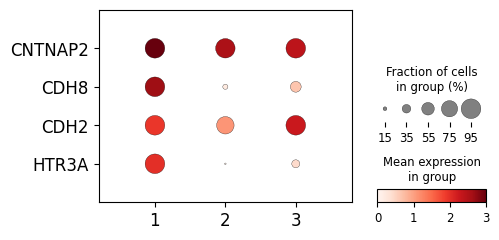

In [20]:
genes = [
   "CNTNAP2", "CDH8", "CDH2", "HTR3A"
]
dp = sc.pl.dotplot(
    sub_adata,
    var_names=genes,
    groupby="cell_group",
    figsize=(5, 2.5),   # width, height in inches
    dot_min=0.05,
    dot_max=0.95,
    swap_axes=True,
    show=False,
    return_fig=True,
    vmin=0,
    vmax=3
)
ax = dp.get_axes()["mainplot_ax"]
ax.tick_params(axis="x", labelrotation=0, labelsize=12)
ax.tick_params(axis="y", labelsize=12)
dp.fig.savefig("../paper/supp/SN_ASD.pdf", bbox_inches="tight")

Serotonin ($5\text{-HT}$) Overload: IPANs are the primary sensors for serotonin released by the gut lining. In ASD, there is often a "high serotonin" state (hyperserotonemia).2 This chronically overstimulates the sensory neurons, leading to a state of sensory "exhaustion" or hypersensitivity.

10.3390/app13052970

Developmental Migration: Recent research (2024/2025) shows that some ASD gene variants (like DYRK1A) actually slow down the migration of neuron progenitors during embryonic development, meaning the gut ends up with a lower density of functional sensory neurons

10.1038/s41467-025-57342-3

## check influ genes in SFARI genes

In [21]:
sf_df = pd.read_csv('../data/mouse_colon/SFARI-Gene_genes_01-13-2025release_03-27-2025export.csv', header=0, index_col=None)
mg = mygene.MyGeneInfo()
results = mg.querymany(sf_df['ensembl-id'], scopes='ensemblgene', fields='entrezgene', species='human')
ensembl2entrez = {r['query']: r.get('entrezgene', None) for r in results}
sf_df['entrez'] = [ensembl2entrez[ens] if ens in ensembl2entrez else None for ens in sf_df['ensembl-id']]
sf_df = sf_df[~pd.isna(sf_df['entrez'])].copy()
hi_conf_genes = sf_df[sf_df['gene-score'] <= 2.0]['entrez'].values

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
11 input query terms found no hit:	['nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan']


In [22]:
hi_conf_genes.size

935

In [23]:
cg_freq_df = pd.crosstab(sub_adata.obs['cell_group'], adata.obs['metacell'])
cg_freq_df = cg_freq_df.div(cg_freq_df.sum(0))
cg_freq_df

metacell,metacell-816,metacell-909,metacell-1588,metacell-2380,metacell-2619,metacell-3596
cell_group,,,,,,
1,1.0,0.0,1.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,1.0


In [24]:
# cell group to mc
tmp = {
    "1": ['metacell-1588', 'metacell-2380', 'metacell-816'],
    "2": ['metacell-909'],
    "3": ['metacell-2619', 'metacell-3596']
}
cell_group_map = {}
for group, mcs in tmp.items():
    for i in mcs:
        cell_group_map[i] = group

In [25]:
# # get influential genes by groups
# cnt_adata = sc.read('../data/mouse_colon/mouse_colon_cnt.h5ad')
# cnt_adata.obs['metacell'] = pd.read_csv('../results/mouse_colon_mc/mc_assign.csv', header=None, index_col=None)[0].values
# cnt_adata.obs['cell_group'] = [cell_group_map[i] if i in cell_group_map else 'other' for i in cnt_adata.obs['metacell']]
# cnt_adata.write('../data/mouse_colon/mouse_colon_cnt_add_cg.h5ad')

f = np.load('../results/mouse_colon_icepop_cg/dfbs__trait-asd.npz', allow_pickle=True)
cg_dfbs = pd.DataFrame(f['dfbs'], index=f['celltypes'], columns=f['genes'])
cg_dfbs = cg_dfbs.loc[['1', '2', '3'], :].copy()

In [26]:
def precision_at_k(df, sfari_hc, k=100):
    sfari_hc = set(sfari_hc)

    precisions = []
    for idx, row in df.iterrows():
        topk_genes = row.sort_values(ascending=False).index[:k]
        hits = sum(g in sfari_hc for g in topk_genes)
        precisions.append(hits / k)

    return pd.Series(precisions, index=df.index, name=f'precision@{k}')

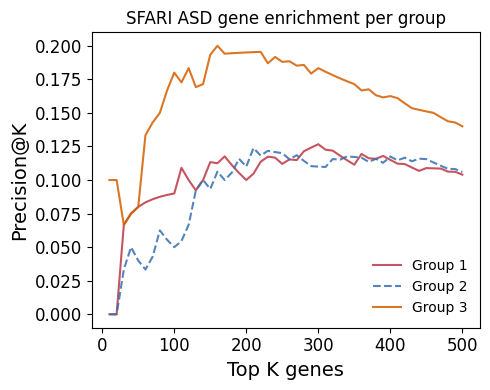

In [27]:
Ks = np.arange(10, 501, 10)

# Color-blind friendly colors
group_colors = {
    "1": "#bc3646",
    "2": "#3570ae",
    "3": "#D55E00",
}

# Line styles per group
group_linestyles = {
    "1": "-",
    "2": "--",
    "3": "-",
}

plt.figure(figsize=(5, 4))

seen_groups = set()

for group in cg_dfbs.index:

    precisions = [
        precision_at_k(cg_dfbs.loc[[group]], hi_conf_genes, k=k).iloc[0]
        for k in Ks
    ]

    plt.plot(
        Ks,
        precisions,
        color=group_colors[group],
        linestyle=group_linestyles[group],
        lw=1.5,
        alpha=0.85,
        label=f"Group {group}"
    )

plt.xlabel("Top K genes", fontsize=14)
plt.ylabel("Precision@K", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("SFARI ASD gene enrichment per group")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('../paper/main/SFARI_enrich_cellgroup.pdf')

## check top influential genes in each cell groups

In [28]:
e2sym = dict(zip(adata.var['hentrez'], adata.var['hsymbol']))
shared_entrez = cg_dfbs.columns.intersection(adata.var['hentrez'].values)
cg_shared_dfbs = cg_dfbs.loc[:, shared_entrez].copy()

In [29]:
cg_df = pd.read_csv('../results/mouse_colon_icepop_cg/celltype__trait-asd.csv', header=0, index_col=0)
cg_df['discovery'] = cg_df['q'] <= 0.1

top_dfbs_df = []
for idx, row in cg_shared_dfbs.iterrows():
    row = row.sort_values(ascending=False)
    row = row[row >= (2 / np.sqrt(cg_dfbs.shape[1]))]
    row = pd.DataFrame(row)
    row = row.reset_index()
    row.columns = ['Entrez', 'Influence score']
    row['Influence score rank'] = row['Influence score'].rank(ascending=False)
    row['Cell group'] = idx
    row['FDR'] = cg_df.loc[idx, 'q']
    row['Associated'] = cg_df.loc[idx, 'discovery']
    top_dfbs_df.append(row)
top_dfbs_df = pd.concat(top_dfbs_df, axis=0, ignore_index=True)
top_dfbs_df['Gene'] = [e2sym[i] for i in top_dfbs_df['Entrez']]
top_dfbs_df['In SFARI'] = top_dfbs_df['Entrez'].isin(sf_df['entrez'])
top_dfbs_df = top_dfbs_df.loc[:, ['Gene', 'Entrez', 'Cell group', 'FDR', 'Associated', 'Influence score', 'Influence score rank', 'In SFARI']].copy()
top_dfbs_df.to_csv('../paper/suppdata/influ_genes_all.tsv', header=True, index=False, sep='\t')

In [30]:
sf_idx_df = sf_df.set_index('entrez')
top_sf_df = top_dfbs_df[top_dfbs_df['In SFARI']].copy()
top_sf_df = top_sf_df.reset_index(drop=True)

top_sf_df = pd.concat(
    [
        top_sf_df,
        sf_idx_df.loc[top_sf_df['Entrez'], :].reset_index(drop=False)
    ],
    axis=1
)
top_sf_df = top_sf_df.drop(columns=['entrez', 'status', 'gene-symbol', 'In SFARI'])
new_order = [
    "Gene", "gene-name", "Entrez", "ensembl-id", "chromosome",
    "Cell group", "FDR", "Associated", "Influence score", 'Influence score rank',
    "genetic-category", "gene-score", "eagle", "syndromic", "number-of-reports"
]
top_sf_df = top_sf_df[new_order]
top_sf_df.to_csv('../paper/suppdata/influ_genes_SFARI.tsv', header=True, index=False, sep='\t')